# GANisme — 03. Construction des datasets et protocole d'évaluation

Ce notebook prépare tout ce qu'il faut **avant** d'entraîner le premier GAN :

1. **Les datasets d'entraînement**, un par genre, au format naturel du genre (portraits verticaux 4:5, paysages
   horizontaux 4:3) plutôt qu'en carré — c'est la réponse au recadrage centré « très moche » du notebook 02.
2. **Les métriques** qui serviront à comparer tous les modèles, et surtout **une échelle pour les lire** : on calcule
   les scores obtenus par des « faux générateurs » connus (images réelles, floutées, bruitées, mode collapse, copie
   pure du train…). Un FID de 45 ne veut rien dire seul ; « entre le flou léger et le flou fort » oui.

Le code est dans deux modules réutilisables, importés ici :

| Module | Rôle |
|---|---|
| `src/dataset.py` | filtres, sélection du genre, recadrage, séparation train/test, chargement des images |
| `src/metrics.py` | extraction Inception-v3, FID, KID, IS, précision/rappel, densité/couverture, mémorisation |

In [1]:
import json
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.ticker as mtick
from PIL import Image, ImageFilter
from matplotlib_inline.backend_inline import set_matplotlib_formats

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
import dataset as ds       # noqa: E402  (project modules)
import metrics as mt       # noqa: E402

set_matplotlib_formats("jpeg", pil_kwargs={"quality": 85})
FIG_DIR = ROOT / "reports" / "figures"
MET_DIR = ROOT / "reports" / "metrics"
MET_DIR.mkdir(parents=True, exist_ok=True)
SEED = 42
rng = np.random.default_rng(SEED)

CAT = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
MAIN, OTHER = CAT[0], "#c3c2b7"
INK, INK2, MUTED, GRID, SURFACE = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#fcfcfb"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "figure.dpi": 110, "savefig.dpi": 150, "savefig.bbox": "tight",
    "font.family": "sans-serif", "font.sans-serif": ["Segoe UI", "DejaVu Sans", "Arial"],
    "font.size": 10, "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.titlecolor": INK, "axes.labelcolor": INK2, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": INK2, "axes.edgecolor": OTHER,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6, "axes.axisbelow": True,
    "legend.frameon": False, "lines.linewidth": 2,
})


def save(fig, name):
    fig.savefig(FIG_DIR / f"{name}.png")


import torch
print("GPU :", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "aucun (CPU)")

GPU : NVIDIA GeForce RTX 5060 Laptop GPU


## 1. Filtres globaux : l'entonnoir

Chaque filtre correspond à un problème identifié dans les notebooks 01 et 02. Ils sont appliqués dans l'ordre ;
le tableau indique combien d'images chacun retire.

| Filtre | Problème | Détection |
|---|---|---|
| Image téléchargée | lien mort (1 œuvre) | statut du scraping |
| Photo d'architecture | façades, cloîtres, intérieurs | `MEDIUM == "Photo"` |
| Monochrome | sculptures, gravures, photos N&B d'œuvres détruites | écart RGB / luminosité < 0,02 |
| Quasi-doublon | détails et vues multiples d'une même œuvre | `IS_NEAR_DUP` (EDA) |
| Fond de studio | tondi et panneaux détourés sur fond gris | 4 coins uniformes et clairs |
| Format extrême | prédelles, volets, frises | ratio hors de [0,5 ; 2] |

In [2]:
table = ds.load_images_table()
filtered, funnel = ds.global_filters(table)

# The module returns English keys; French labels are used for display
STEPS_FR = ["Peintures au catalogue", "Image téléchargée", "Pas une photo d'architecture", "Pas monochrome",
            "Pas un quasi-doublon", "Pas de fond de studio", "Ratio entre 0.5 et 2.0"]
funnel_fr = pd.DataFrame({"étape": STEPS_FR, "restantes": funnel["remaining"], "retirées": funnel["removed"]})
funnel_fr

,étape,restantes,retirées
0,Peintures au catalogue,32438,0
1,Image téléchargée,32437,1
2,Pas une photo d'architecture,32372,65
3,Pas monochrome,32328,44
4,Pas un quasi-doublon,26538,5790
5,Pas de fond de studio,26161,377
6,Ratio entre 0.5 et 2.0,24860,1301


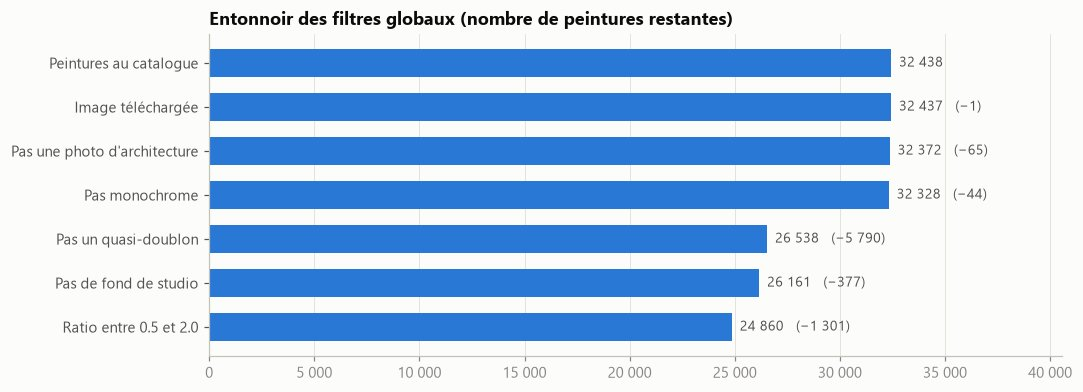

In [3]:
fig, ax = plt.subplots(figsize=(10, 3.8))
f = funnel_fr.iloc[::-1]
ax.barh(f["étape"], f["restantes"], color=MAIN, height=0.65)
for i, (r, rm) in enumerate(zip(f["restantes"], f["retirées"])):
    ax.text(r, i, f"  {r:,}".replace(",", " ") + (f"   (−{rm:,})".replace(",", " ") if rm else ""),
            va="center", fontsize=9, color=INK2)
ax.set_xlim(0, funnel_fr["restantes"].max() * 1.25); ax.grid(axis="y", visible=False)
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"{v:,.0f}".replace(",", " ")))
ax.set_title("Entonnoir des filtres globaux (nombre de peintures restantes)")
save(fig, "ds_01_funnel")
plt.show()

**Observations** — les filtres conservent **24 860 peintures sur 32 438 (77 %)**. Le filtre le plus coûteux est celui
des quasi-doublons (−5 790), suivi des formats extrêmes (−1 301). Les filtres « photo » et « monochrome » retirent peu
d'images (65 et 44), mais ce sont de vrais intrus : des images qui ne ressemblent pas du tout à des peintures et qui
pollueraient la distribution apprise.

## 2. Un format par genre

Plutôt que de forcer toutes les images dans un carré, chaque genre a son **format cible**, choisi d'après la
distribution réelle des ratios (notebook 02) :

| Genre | Format | Résolutions (largeur × hauteur) | Recadrage vertical |
|---|---|---|---|
| Portrait | 4:5 vertical | 64×80 puis 128×160 | remonté (0,4) : le visage est dans le tiers supérieur |
| Paysage | 4:3 horizontal | 64×48 puis 128×96 | centré |

Les deux résolutions ont le même ratio : on pourra entraîner en 64 puis passer en 128 sans refaire le dataset.
On ne garde que les images dont le recadrage au format cible coupe **au plus 25 % de la surface**.

portrait   ratio cible = 0.80  résolutions = [(64, 80), (128, 160)]  center_y = 0.4
landscape  ratio cible = 1.33  résolutions = [(64, 48), (128, 96)]  center_y = 0.5


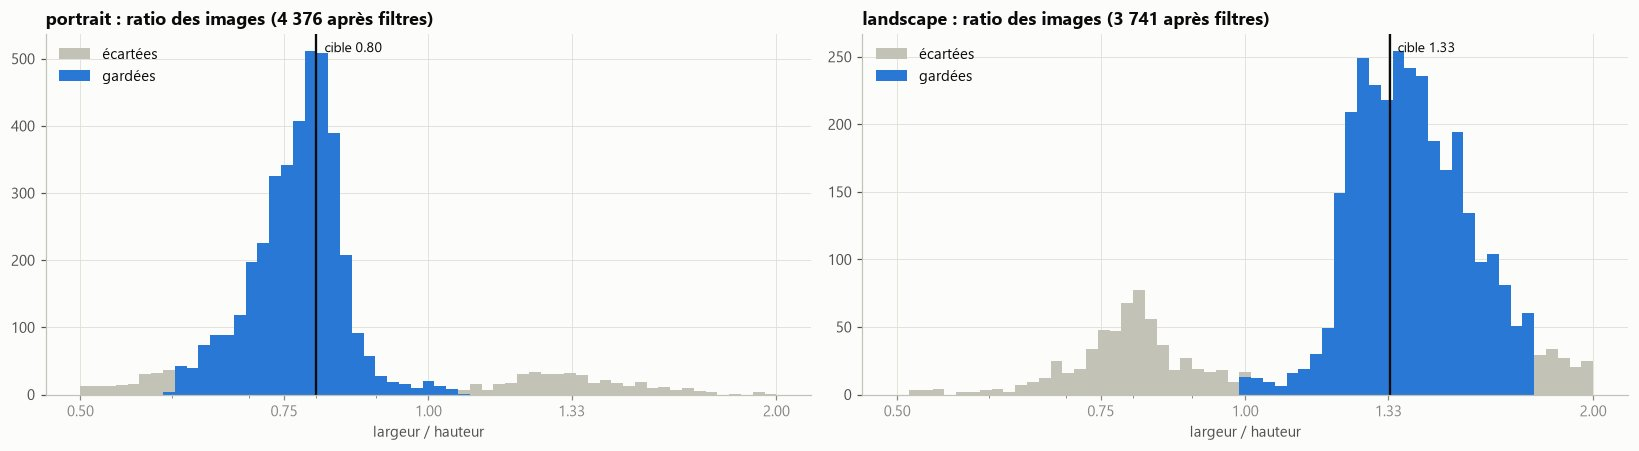

In [4]:
for name, cfg in ds.GENRES.items():
    print(f"{name:10s} ratio cible = {cfg.aspect:.2f}  résolutions = {cfg.resolutions()}  center_y = {cfg.center_y}")

fig, axes = plt.subplots(1, 2, figsize=(15, 4.2))
for ax, (name, cfg) in zip(axes, ds.GENRES.items()):
    g = filtered[filtered["TYPE"].isin(cfg.types)]
    lo = cfg.aspect * (1 - cfg.max_crop_loss)          # aspect-ratio bounds for a loss ≤ 25 %
    hi = cfg.aspect / (1 - cfg.max_crop_loss)
    bins = np.logspace(np.log10(0.5), np.log10(2), 60)
    ax.hist(g["IMG_ASPECT"], bins=bins, color=OTHER, label="écartées")
    ax.hist(g.loc[g["IMG_ASPECT"].between(lo, hi), "IMG_ASPECT"], bins=bins, color=MAIN, label="gardées")
    ax.axvline(cfg.aspect, color=INK, lw=1.5)
    ax.text(cfg.aspect, ax.get_ylim()[1] * 0.95, f"  cible {cfg.aspect:.2f}", fontsize=9)
    ax.set_xscale("log"); ax.set_xticks([0.5, 0.75, 1, 1.33, 2])
    ax.xaxis.set_major_formatter(mtick.ScalarFormatter()); ax.xaxis.set_minor_formatter(mtick.NullFormatter())
    ax.set_title(f"{name} : ratio des images ({len(g):,} après filtres)".replace(",", " "))
    ax.set_xlabel("largeur / hauteur"); ax.legend(loc="upper left")
plt.tight_layout()
save(fig, "ds_02_aspect_selection")
plt.show()

### 2.1 Recadrage et redimensionnement

`ImageOps.fit` découpe la plus grande fenêtre au bon ratio, puis redimensionne avec un filtre **Lanczos**.
Ce filtre moyenne les pixels avant de réduire : sans lui, la réduction de 400 à 64 px ferait apparaître du
crénelage et du moiré, que le GAN apprendrait à reproduire. En rouge, la zone conservée.

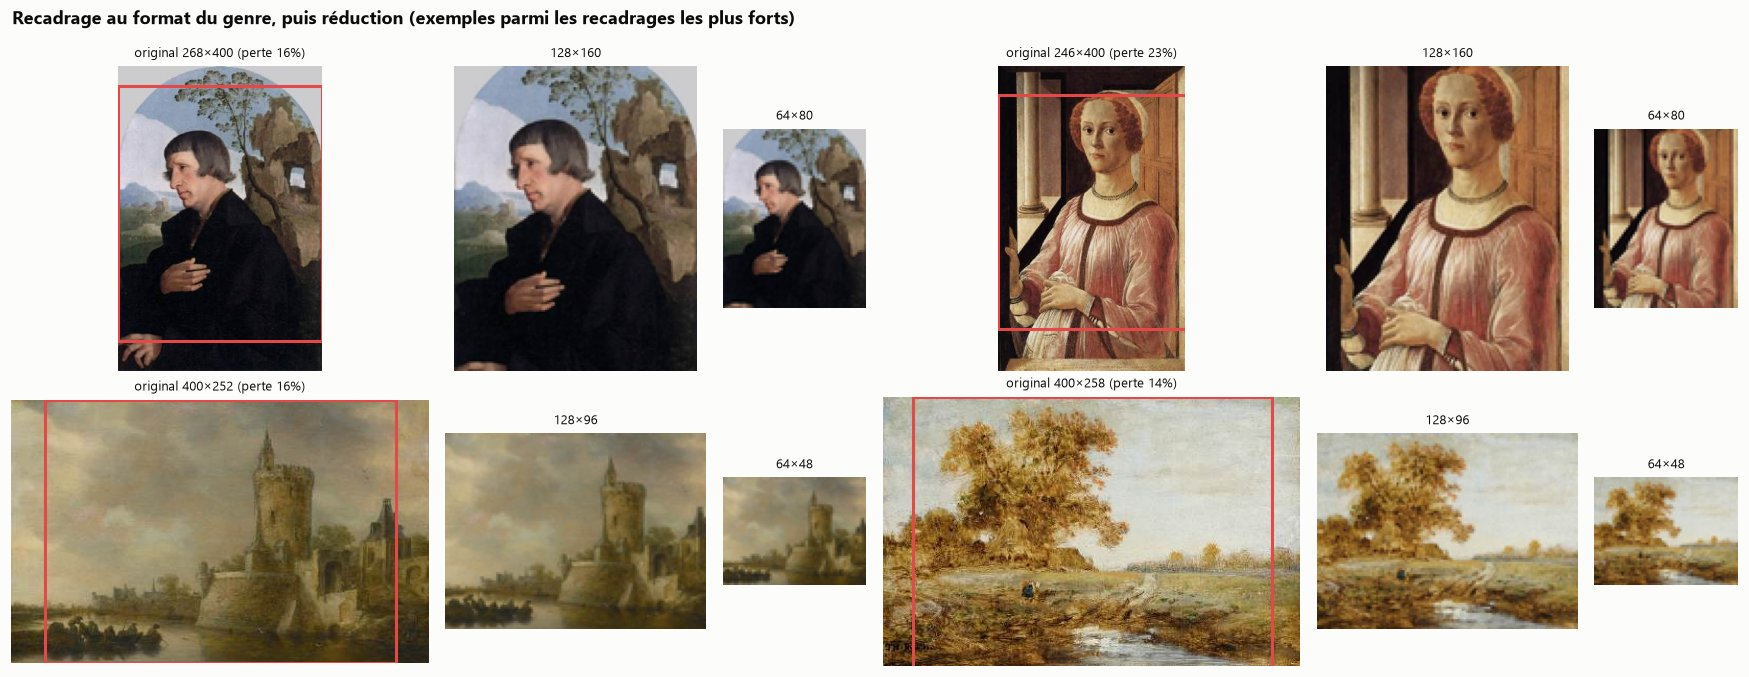

In [5]:
def crop_box(w, h, target, center_y):
    # Same computation as ImageOps.fit: largest window with the target aspect ratio, positioned by center_y
    if w / h > target:
        cw, ch = h * target, h
    else:
        cw, ch = w, w / target
    return (w - cw) * 0.5, (h - ch) * center_y, cw, ch


fig, axes = plt.subplots(2, 6, figsize=(16, 6.4), gridspec_kw={"width_ratios": [1.6, 1, 0.55] * 2})
for row, name in enumerate(ds.GENRES):
    cfg = ds.GENRES[name]
    g = filtered[filtered["TYPE"].isin(cfg.types)]
    g = g[ds.crop_loss(g["IMG_ASPECT"], cfg.aspect).between(0.12, 0.25)].sample(2, random_state=3)
    for k, (_, r) in enumerate(g.iterrows()):
        a0, a1, a2 = axes[row, 3 * k], axes[row, 3 * k + 1], axes[row, 3 * k + 2]
        with Image.open(ROOT / r["local_path"]) as im:
            im = im.convert("RGB")
            a0.imshow(im)
            x, y, cw, ch = crop_box(*im.size, cfg.aspect, cfg.center_y)
            a0.add_patch(patches.Rectangle((x, y), cw, ch, fill=False, ec=CAT[7], lw=2))
            big = ds.crop_and_resize(ROOT / r["local_path"], cfg.size, cfg.center_y)
            small = big.resize(cfg.resolutions()[0], Image.LANCZOS)
        a1.imshow(big); a2.imshow(small)
        a0.set_title(f"original {im.size[0]}×{im.size[1]} (perte {ds.crop_loss(r['IMG_ASPECT'], cfg.aspect):.0%})",
                     fontsize=8.5, loc="center", fontweight="normal")
        a1.set_title(f"{cfg.size[0]}×{cfg.size[1]}", fontsize=8.5, loc="center", fontweight="normal")
        a2.set_title(f"{cfg.resolutions()[0][0]}×{cfg.resolutions()[0][1]}", fontsize=8.5, loc="center", fontweight="normal")
        for a in (a0, a1, a2):
            a.axis("off")
fig.suptitle("Recadrage au format du genre, puis réduction (exemples parmi les recadrages les plus forts)",
             x=0.01, ha="left", fontsize=12, fontweight="bold")
plt.tight_layout()
save(fig, "ds_03_crop_examples")
plt.show()

### 2.2 Construction et séparation train / test

10 % des œuvres sont mises de côté (**test**). Elles ne serviront jamais à l'entraînement ; elles donnent :
- le **plancher** des métriques : le score qu'obtiendrait un générateur parfait, qui produirait des tableaux
  aussi différents du train que de vraies œuvres nouvelles ;
- l'étalon du **test de mémorisation** : à quelle distance du train se trouve une œuvre réellement nouvelle ?

La séparation se fait **par œuvre** (auteur + titre de base) : deux versions d'un même tableau restent du même côté.

In [6]:
summary = {"global_filters": funnel.to_dict("records"), "genres": {}}
for name, cfg in ds.GENRES.items():
    t0 = time.time()
    summary["genres"][name] = ds.build_genre(filtered, cfg, force=True)
    print(f"{name:10s} construit en {time.time() - t0:.1f} s")
(ds.DATASETS / "summary.json").write_text(json.dumps(summary, indent=2, ensure_ascii=False), encoding="utf-8")

pd.DataFrame(summary["genres"]).T[["size", "genre_after_filters", "removed_by_format", "compatible_format",
                                    "train", "test", "median_crop_loss"]].rename(columns={
    "genre_after_filters": "genre_après_filtres", "removed_by_format": "retirées_format",
    "compatible_format": "format_compatible", "median_crop_loss": "perte_recadrage_médiane"})

portrait   construit en 5.4 s


landscape  construit en 3.3 s


,size,genre_après_filtres,retirées_format,format_compatible,train,test,perte_recadrage_médiane
portrait,"(128, 160)",4376,544,3832,3448,384,0.049
landscape,"(128, 96)",3741,725,3016,2714,302,0.071


In [7]:
# Is the test set representative? Distributions by century and by school are compared.
rows = []
for name in ds.GENRES:
    meta = pd.read_csv(ds.DATASETS / name / "metadata.csv")
    for col in ["CENTURY", "SCHOOL"]:
        top = meta[col].value_counts().index[:5]
        ct = pd.crosstab(meta[col].where(meta[col].isin(top), "autres"), meta["SPLIT"], normalize="columns")
        ct.index = [f"{name} · {col} · {v}" for v in ct.index]
        rows.append(ct)
(pd.concat(rows) * 100).round(1).rename(columns={"test": "% test", "train": "% train"})

SPLIT,% test,% train
portrait · CENTURY · 15,8.6,7.2
portrait · CENTURY · 16,25.8,25.5
portrait · CENTURY · 17,25.5,27.3
portrait · CENTURY · 18,16.9,19.5
portrait · CENTURY · 19,23.2,20.3
portrait · CENTURY · autres,0.0,0.1
portrait · SCHOOL · Dutch,20.1,16.2
portrait · SCHOOL · Flemish,13.3,11.3
portrait · SCHOOL · French,19.0,19.3
portrait · SCHOOL · German,7.0,10.2


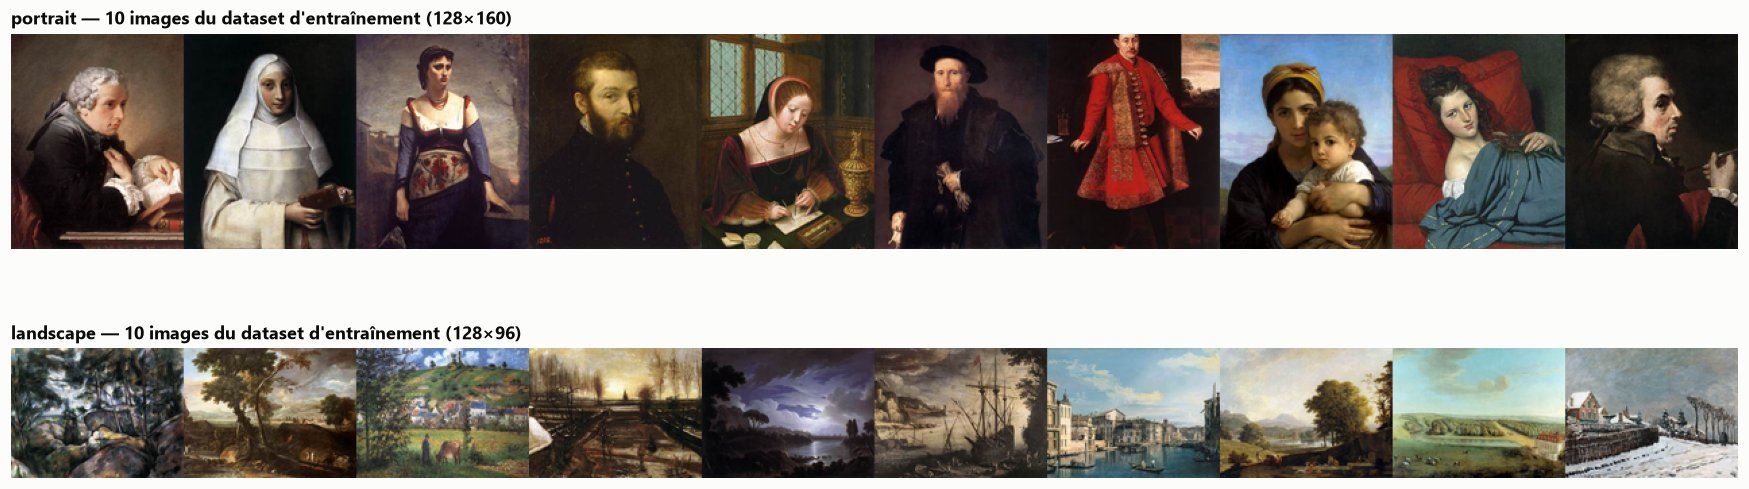

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(16, 5.6), gridspec_kw={"height_ratios": [160, 96]})
for ax, name in zip(axes, ds.GENRES):
    meta = pd.read_csv(ds.DATASETS / name / "metadata.csv")
    s = meta[meta["SPLIT"] == "train"].sample(10, random_state=SEED)
    tiles = [np.asarray(Image.open(ds.DATASETS / name / f)) for f in s["FILE"]]
    ax.imshow(np.concatenate(tiles, axis=1)); ax.axis("off")
    ax.set_title(f"{name} — 10 images du dataset d'entraînement ({ds.GENRES[name].size[0]}×{ds.GENRES[name].size[1]})")
plt.tight_layout()
save(fig, "ds_04_final_samples")
plt.show()

**Observations**

- **Portraits** : 4 376 après filtres, dont 3 832 compatibles avec le format 4:5 (les 544 écartés sont surtout des
  portraits horizontaux : doubles portraits, portraits de groupe) → **3 448 train / 384 test**.
- **Paysages** : 3 741 après filtres, dont 3 016 compatibles avec le 4:3 (725 écartés : paysages verticaux ou panoramas)
  → **2 714 train / 302 test**.
- La **perte médiane au recadrage tombe à 4,9 % (portraits) et 7,1 % (paysages)**, contre 25 % avec un recadrage carré.
  Sur les exemples les plus recadrés, les têtes restent entières grâce au recadrage remonté (Botticelli, en haut à droite).
- Le **test set est représentatif** : répartitions par siècle et par école à quelques points près de celles du train
  (les écarts, comme 20 % contre 16 % d'école hollandaise, relèvent du bruit d'échantillonnage sur 384 images).
- Point de vigilance : **3 448 et 2 714 images, c'est peu pour un GAN**. Le discriminateur risque d'apprendre le train
  par cœur ; la métrique de mémorisation et, si besoin, une augmentation de type DiffAugment / ADA serviront à le contrôler.

## 3. Les métriques d'évaluation

Évaluer un GAN est difficile (cf. veille, question 7) : il n'y a pas de « bonne réponse » à laquelle comparer une
image générée. On compare donc des **distributions** : celle des images générées et celle des vraies peintures.
Toutes les métriques travaillent dans l'espace des **features d'Inception-v3** (vecteur de 2048 valeurs par image),
plus proche de la perception que les pixels bruts.

| Métrique | Question posée | Lecture | Point faible |
|---|---|---|---|
| **FID** | Les deux nuages de features ont-ils la même moyenne et la même dispersion ? | ↓ (0 = identiques) | biaisé par la taille d'échantillon ; mélange qualité et diversité |
| **KID** | Idem, via un noyau polynomial | ↓ (0) | plus bruité ; affiché ×1000 |
| **IS** | Les images sont-elles nettes et variées au sens des classes ImageNet ? | ↑ | classes ImageNet ≠ catégories de peinture : **indicatif seulement** |
| **Précision** | Quelle part des images générées ressemble à de vraies peintures ? | ↑ (1) | → **qualité** |
| **Rappel** | Quelle part de la variété réelle le générateur sait-il produire ? | ↑ (1) | → **diversité** (détecte le mode collapse) |
| **Densité** | Précision pondérée, robuste aux images réelles atypiques | ↑ (≈ 1) | peut dépasser 1 |
| **Couverture** | Rappel robuste aux images réelles atypiques | ↑ (1) | |
| **Mémorisation** | Les images générées sont-elles plus proches du train qu'une œuvre nouvelle ne l'est ? | ≈ 1 | ≪ 1 = copie |

Le **FID** reste la métrique principale (standard de la littérature) ; **précision et rappel** expliquent *pourquoi*
un FID est mauvais (images ratées ou manque de diversité) ; la **mémorisation** vérifie qu'un bon score n'est pas
obtenu en recopiant les données — ce qui est un vrai risque avec seulement ~3 000 images.

### 3.1 Features de référence

Les features des images réelles sont calculées une fois par genre et par résolution, puis mises en cache.

In [9]:
REFS = {}
for name, cfg in ds.GENRES.items():
    for size in cfg.resolutions():
        t0 = time.time()
        REFS[(name, size)] = mt.Reference.load_or_compute(name, size, ds.DATASETS / name)
        r = REFS[(name, size)]
        print(f"{name:10s} {size[0]}×{size[1]:<4} train {r.train.shape}  test {r.test.shape}  ({time.time() - t0:.1f} s)")

portrait   64×80   train (3448, 2048)  test (384, 2048)  (0.3 s)


portrait   128×160  train (3448, 2048)  test (384, 2048)  (0.3 s)


landscape  64×48   train (2714, 2048)  test (302, 2048)  (0.2 s)


landscape  128×96   train (2714, 2048)  test (302, 2048)  (0.2 s)


### 3.2 Une échelle de lecture : les scores de « faux générateurs »

Pour savoir ce que valent les scores de nos futurs GAN, on évalue des générateurs fictifs dont on connaît le
défaut. Chaque ensemble a la **même taille que le train** (N_EVAL), comme le seront les lots d'images générées :

| Faux générateur | Ce qu'il simule |
|---|---|
| **Réel non vu (test)** | le générateur idéal : de vraies œuvres, nouvelles *(N plus petit : FID gonflé, lire le KID)* |
| **Copie du train** | un générateur qui a tout mémorisé : scores parfaits… sauf la mémorisation |
| **Flou léger / fort** | un générateur qui a la bonne composition mais pas les détails (typique des débuts) |
| **Bruit** | un générateur aux textures parasites (artefacts haute fréquence) |
| **Mode collapse** | un générateur qui ne sait produire que 20 tableaux différents |
| **Image moyenne** | un générateur effondré sur une seule image floue |
| **Bruit pur** | un générateur non entraîné |

In [10]:
def degrade(images, kind):
    # Build a fake set of generated images from the real training images.
    if kind == "copy":
        return images
    if kind.startswith("blur"):
        radius = {"blur_light": 1.0, "blur_strong": 2.5}[kind]
        return np.stack([np.asarray(Image.fromarray(x).filter(ImageFilter.GaussianBlur(radius))) for x in images])
    if kind == "noise":
        return np.clip(images + rng.normal(0, 25, images.shape), 0, 255).astype(np.uint8)
    if kind == "collapse":
        pool = images[rng.choice(len(images), 20, replace=False)]
        return pool[rng.integers(0, 20, len(images))]
    if kind == "mean":
        mean = images.mean(0, keepdims=True)
        return np.clip(mean + rng.normal(0, 3, images.shape), 0, 255).astype(np.uint8)
    if kind == "pure_noise":
        return rng.integers(0, 256, images.shape, dtype=np.uint8)
    raise ValueError(kind)


BASELINES = {"blur_light": "Flou léger", "blur_strong": "Flou fort", "noise": "Bruit (σ=25)",
             "collapse": "Mode collapse (20 images)", "mean": "Image moyenne", "pure_noise": "Bruit pur",
             "copy": "Copie du train"}

results = []
for name, cfg in ds.GENRES.items():
    for size in cfg.resolutions():
        ref = REFS[(name, size)]
        train_imgs = ds.load_split(name, "train", size)
        t0 = time.time()
        results.append({"genre": name, "résolution": f"{size[0]}×{size[1]}", "baseline": "Réel non vu (test)",
                        **mt.evaluate(ref.test, ref.test_logits, ref)})
        for key, label in BASELINES.items():
            feats, logits = mt.extract_features(degrade(train_imgs, key))
            results.append({"genre": name, "résolution": f"{size[0]}×{size[1]}", "baseline": label,
                            **mt.evaluate(feats, logits, ref)})
        print(f"{name:10s} {size[0]}×{size[1]:<4} : 8 baselines en {time.time() - t0:.0f} s")

baselines = pd.DataFrame(results)
baselines.to_csv(MET_DIR / "baselines.csv", index=False)
COLS = ["n", "FID", "FID_ntest", "KID_x1000", "IS", "precision", "recall", "density", "coverage", "mem_ratio", "copies"]
baselines.set_index(["genre", "résolution", "baseline"])[COLS].round(3)

portrait   64×80   : 8 baselines en 219 s


portrait   128×160  : 8 baselines en 219 s


landscape  64×48   : 8 baselines en 201 s


landscape  128×96   : 8 baselines en 187 s


n      FID  FID_ntest  \
genre     résolution baseline                                              
portrait  64×80      Réel non vu (test)          384   57.562     57.562   
                     Flou léger                 3448   61.232    106.555   
                     Flou fort                  3448  203.407    241.989   
                     Bruit (σ=25)               3448  113.950    157.661   
                     Mode collapse (20 images)  3448  196.333    197.167   
                     Image moyenne              3448  493.059    497.881   
                     Bruit pur                  3448  485.639    492.055   
                     Copie du train             3448   -0.000     49.037   
          128×160    Réel non vu (test)          384   60.819     60.819   
                     Flou léger                 3448   21.230     70.660   
                     Flou fort                  3448  106.176    154.475   
                     Bruit (σ=25)               3448   71.116    119.533   
                     Mode collapse (20 images)  3448  209.227    209.738   
                     Image moyenne              3448  494.396    499.323   
                     Bruit pur                  3448  474.270    481.272   
                     Copie du train             3448   -0.000     52.238   
landscape 64×48      Réel non vu (test)          302   58.485     58.485   
                     Flou léger                 2714   92.654    140.864   
                     Flou fort                  2714  263.854    298.164   
                     Bruit (σ=25)               2714  147.553    193.876   
                     Mode collapse (20 images)  2714  185.322    183.440   
                     Image moyenne              2714  500.505    506.377   
                     Bruit pur                  2714  450.941    459.731   
                     Copie du train             2714    0.000     50.104   
          128×96     Réel non vu (test)          302   55.490     55.490   
                     Flou léger                 2714   46.874     91.343   
                     Flou fort                  2714  179.484    223.749   
                     Bruit (σ=25)               2714   85.803    131.878   
                     Mode collapse (20 images)  2714  185.599    187.701   
                     Image moyenne              2714  481.518    486.610   
                     Bruit pur                  2714  413.039    420.343   
                     Copie du train             2714    0.000     46.728   

                                                KID_x1000     IS  precision  \
genre     résolution baseline                                                 
portrait  64×80      Réel non vu (test)            -0.223  3.861      0.776   
                     Flou léger                    56.554  4.554      0.684   
                     Flou fort                    213.972  3.426      0.026   
                     Bruit (σ=25)                 121.322  4.392      0.141   
                     Mode collapse (20 images)     15.759  3.686      1.000   
                     Image moyenne                643.099  1.094      0.000   
                     Bruit pur                    637.686  1.090      0.000   
                     Copie du train                -0.217  4.491      1.000   
          128×160    Réel non vu (test)            -0.279  4.188      0.760   
                     Flou léger                    11.047  4.827      0.993   
                     Flou fort                     84.662  4.324      0.142   
                     Bruit (σ=25)                  68.657  4.924      0.423   
                     Mode collapse (20 images)     15.903  3.918      1.000   
                     Image moyenne                635.941  1.058      0.000   
                     Bruit pur                    596.275  1.086      0.000   
                     Copie du train                -0.210  5.185      1.000   
landscape 64×48      Réel non vu (test)     

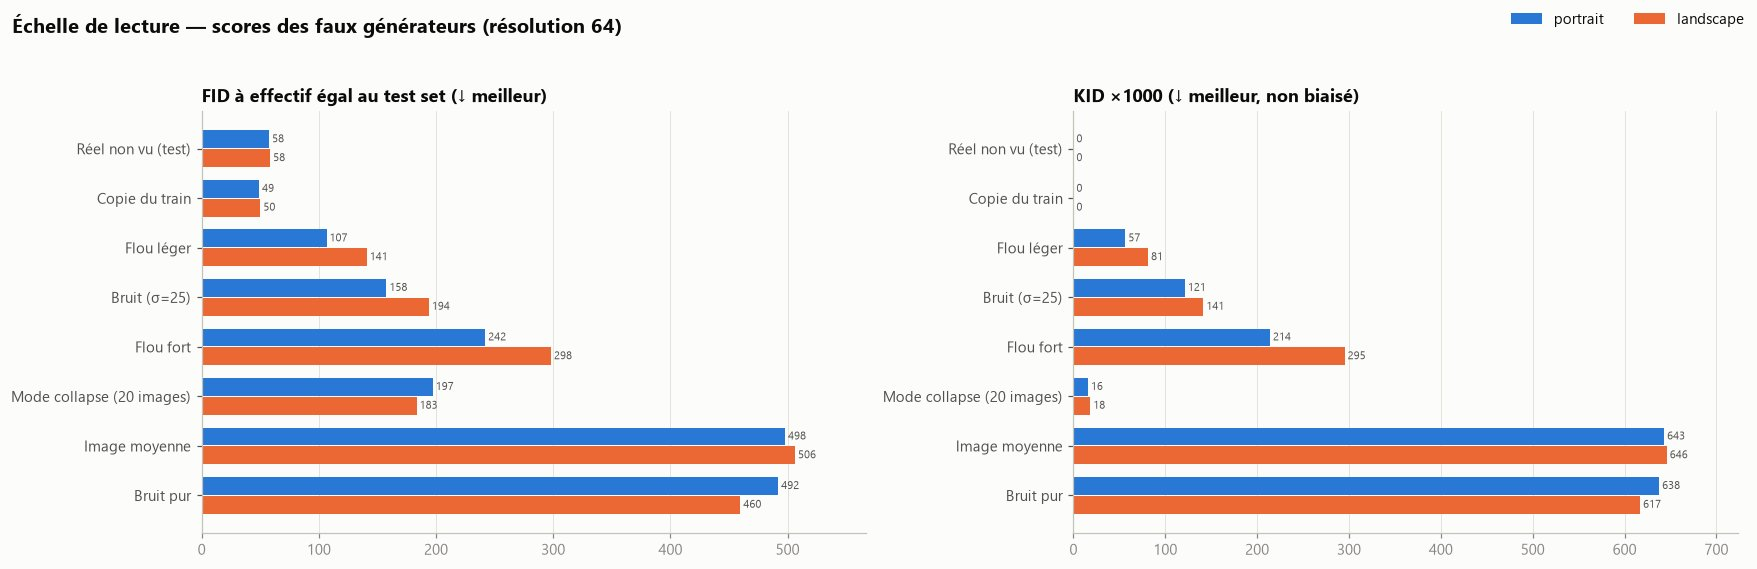

In [11]:
order = ["Réel non vu (test)", "Copie du train", "Flou léger", "Bruit (σ=25)", "Flou fort",
         "Mode collapse (20 images)", "Image moyenne", "Bruit pur"]
low = baselines[baselines["résolution"].isin(["64×80", "64×48"])]

fig, axes = plt.subplots(1, 2, figsize=(16, 5.2))
panels = [(axes[0], "FID_ntest", "FID à effectif égal au test set (↓ meilleur)"),
          (axes[1], "KID_x1000", "KID ×1000 (↓ meilleur, non biaisé)")]
for ax, metric, title in panels:
    y = np.arange(len(order))
    for j, name in enumerate(ds.GENRES):
        v = low[low["genre"] == name].set_index("baseline").loc[order, metric].clip(lower=0)
        ax.barh(y + (j - 0.5) * 0.38, v, height=0.36, color=CAT[j], label=name)
        for yi, vi in zip(y, v):
            ax.text(vi, yi + (j - 0.5) * 0.38, f" {vi:.0f}", va="center", fontsize=7.5, color=INK2)
    ax.set_yticks(y, order); ax.invert_yaxis()
    ax.set_xlim(0, low[metric].max() * 1.12)
    ax.set_title(title); ax.grid(axis="y", visible=False)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right", ncol=2)
fig.suptitle("Échelle de lecture — scores des faux générateurs (résolution 64)", x=0.01, ha="left",
             fontsize=13, fontweight="bold")
plt.tight_layout(rect=(0, 0, 1, 0.95))
save(fig, "ds_05_baselines_fid_kid")
plt.show()

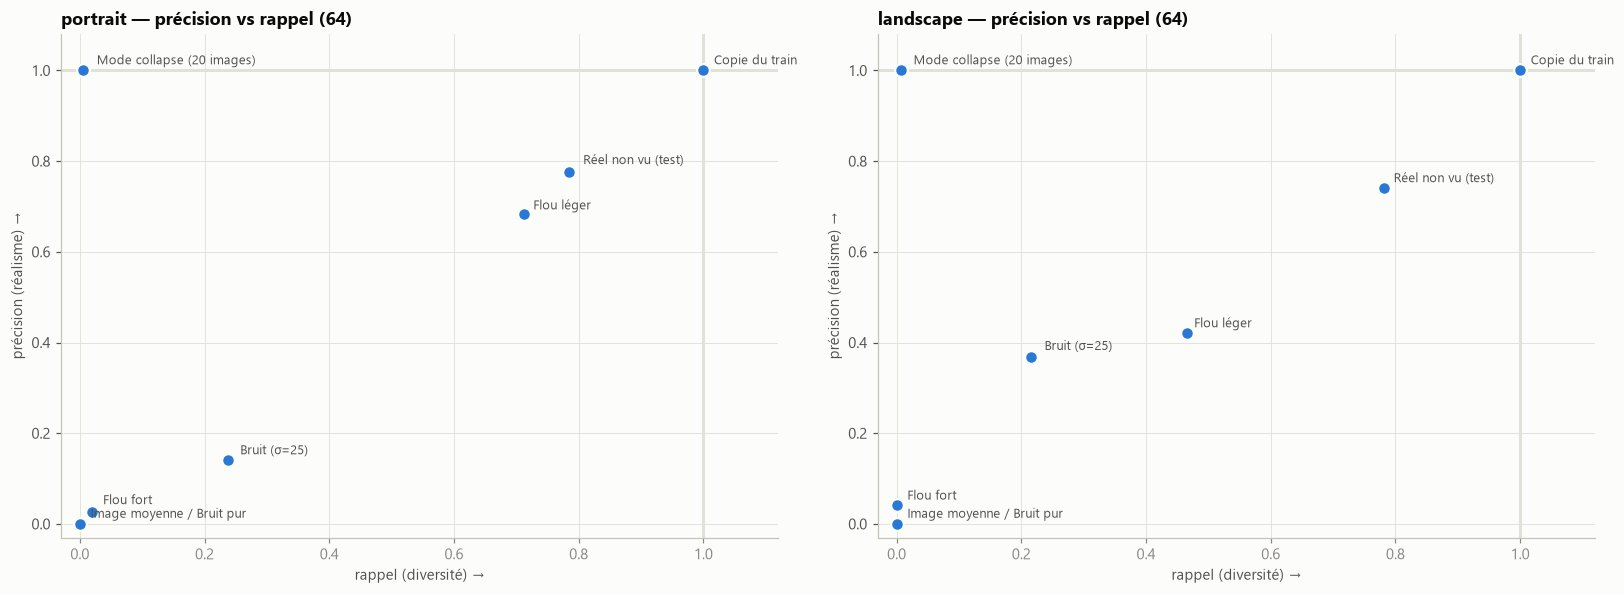

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
for ax, name in zip(axes, ds.GENRES):
    d = low[low["genre"] == name].set_index("baseline").loc[order]
    ax.scatter(d["recall"], d["precision"], s=70, color=MAIN, zorder=3, edgecolor=SURFACE, linewidth=1.5)
    # Overlapping points (e.g. pure noise and mean image, both at (0, 0)) share one label
    groups = d.groupby([d["recall"].round(2), d["precision"].round(2)]).apply(lambda g: " / ".join(g.index))
    for (x, y), lbl in groups.items():
        ax.annotate(lbl, (x, y), xytext=(7, 4), textcoords="offset points", fontsize=8.5, color=INK2)
    ax.set_xlim(-0.03, 1.12); ax.set_ylim(-0.03, 1.08)
    ax.set_xlabel("rappel (diversité) →"); ax.set_ylabel("précision (réalisme) →")
    ax.set_title(f"{name} — précision vs rappel (64)")
    ax.axhline(1, color=GRID); ax.axvline(1, color=GRID)
plt.tight_layout()
save(fig, "ds_06_baselines_precision_recall")
plt.show()

**Comment lire les métriques — ce que montrent les faux générateurs**

1. **Le FID est biaisé par la taille d'échantillon.** Avec 384 images, même une copie exacte du train obtient un FID
   de **49**, et de vraies œuvres jamais vues **58**. On ne peut donc jamais espérer 0 : à effectif égal au test set,
   **un FID ≈ 50-60 correspond à un générateur parfait**. C'est pourquoi `evaluate` renvoie aussi `FID_ntest`.

2. **L'échelle de lecture** (portraits en 64×80, `FID_ntest`) :

   | FID_ntest | Ce que ça veut dire |
   |---|---|
   | ≈ 50-60 | indiscernable de vraies peintures |
   | ≈ 110 | bonne composition, détails flous (flou léger) |
   | ≈ 160 | textures parasites (bruit) |
   | ≈ 200 | diversité effondrée (mode collapse) |
   | ≈ 240 | images très floues (flou fort) |
   | ≈ 500 | générateur non entraîné |

   Les paysages suivent la même logique, avec un flou plus pénalisant (141 contre 107) : leurs détails fins
   (feuillages, nuages) portent une grande part de l'information.

3. **Les scores dépendent de la résolution.** Le même flou d'1 pixel coûte beaucoup moins en 128 qu'en 64 (FID 21
   contre 61 à N complet) : en 128, 1 pixel représente une plus petite part de l'image. **On ne compare donc les modèles
   qu'à résolution égale.**

4. **Chaque métrique a un angle mort, d'où l'intérêt de les combiner :**
   - le **KID** est bien non biaisé (≈ 0 pour le réel non vu), mais il **détecte mal le mode collapse** : 16, soit
     mieux que le flou léger (57) ! Le FID (197) et surtout le **rappel (0,01)** le détectent clairement ;
   - le graphique **précision / rappel** sépare les types d'échec : le mode collapse est en haut à gauche (images
     parfaites mais toujours les mêmes), le flou et le bruit sur la diagonale basse (images ratées). Le réel non vu se
     place vers **(0,78 ; 0,78)** : c'est le plafond réaliste, pas (1 ; 1) ;
   - la **copie du train** a des scores parfaits partout… sauf en **mémorisation** (`mem_ratio` = 0, 100 % de copies).
     Sans cette métrique, un générateur qui recopie ses données passerait pour le meilleur modèle. La métrique est
     sensible : même des copies légèrement floutées sont détectées (45 % de copies en 128) ;
   - la **couverture** du réel non vu n'est que de 0,40 parce qu'il n'y a que 384 images face à 3 448 : elle ne se
     compare qu'à effectif égal ;
   - l'**Inception Score** n'est pas fiable sur de la peinture : le bruit (4,4) y fait aussi bien que la copie du train
     (4,5). Il est calculé pour mémoire, mais n'entrera dans aucune décision.

## 4. Protocole d'évaluation des futurs modèles

Pour que les comparaisons soient valides, **tous les modèles seront évalués de la même façon** :

| Paramètre | Valeur | Pourquoi |
|---|---|---|
| Référence | features du **train** du genre, à la résolution du modèle | le générateur doit reproduire la distribution qu'il a apprise |
| Nombre d'images générées | **N_EVAL = taille du train** (3 448 portraits, 2 714 paysages) | le FID dépend de N : même N que les baselines ci-dessus |
| Graine | fixe (`SEED = 42`) pour les vecteurs latents d'évaluation | reproductibilité |
| Métriques | FID, KID, IS, précision, rappel, densité, couverture, mémorisation | `metrics.evaluate(...)` |
| Suivi pendant l'entraînement | FID + précision/rappel toutes les N époques, grille d'images à bruit fixe | repérer le meilleur checkpoint et le mode collapse |
| Archivage | une ligne par (modèle, checkpoint) dans `reports/metrics/` | tableau comparatif final pour la présentation |

Un modèle se lira toujours **par rapport aux baselines** : par exemple *« FID entre le flou léger et le flou fort,
précision correcte mais rappel faible → images plausibles mais peu variées »*.

In [13]:
# Usage example — this is exactly what the training loop will do:
#
#   ref = mt.Reference.load_or_compute("portrait", (64, 80), ds.DATASETS / "portrait")
#   z = torch.randn(N_EVAL, latent_dim, generator=torch.Generator().manual_seed(42))
#   fake = mt.to_uint8(G(z.to(device)))                   # tanh output [-1, 1] -> uint8
#   feats, logits = mt.extract_features(fake)
#   scores = mt.evaluate(feats, logits, ref)
#
N_EVAL = {name: len(REFS[(name, ds.GENRES[name].resolutions()[0])].train) for name in ds.GENRES}
N_EVAL

{'portrait': 3448, 'landscape': 2714}

## 5. Synthèse

**Datasets prêts** (`data/datasets/<genre>/`) :

| | Portraits | Paysages |
|---|---|---|
| Format | 4:5 vertical | 4:3 horizontal |
| Résolutions | 64×80 → 128×160 | 64×48 → 128×96 |
| Train / test | 3 448 / 384 | 2 714 / 302 |
| Perte médiane au recadrage | 4,9 % | 7,1 % |

**Grille d'évaluation retenue pour tous les modèles** :

| Rôle | Métrique | Cible |
|---|---|---|
| Classement principal | **FID** (N = taille du train) | le plus bas possible |
| Comparaison au plancher | **FID_ntest**, **KID** | FID_ntest → 50-60 ; KID → 0 |
| Diagnostic qualité / diversité | **précision**, **rappel** (+ densité, couverture) | → 0,78 / 0,78 (niveau du réel non vu) |
| Garde-fou | **mémorisation** (`mem_ratio`, `copies`) | ≈ 1 et ≈ 1 % |
| Pour mémoire | IS | non utilisé pour décider |

Les scores de référence sont archivés dans `reports/metrics/baselines.csv` et serviront de repères dans le tableau
comparatif final.

**Étape suivante** : entraîner un premier **DCGAN sur les portraits en 64×80**, en suivant ces métriques pendant
l'entraînement.